In [1]:
import sympy as sp
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- STEP 1: Symbolic Derivation ---
# Define symbols: s (Laplace variable), t (time), 
# and functions Y(s), X(s)
s = sp.symbols('s')
Y = sp.Function('Y')(s)
X = sp.Function('X')(s)

In [3]:
# The D operator in the time domain corresponds to multiplying by 's' 
# in the Laplace domain (assuming zero initial conditions).
# Equation: 2*D**2*y + D*y = D*x + x
# Becomes: 2*(s**2)*Y + s*Y = s*X + X

output = 2*s**2 * Y + s * Y 
input = s * X + X           

# Define the equation: output = input
equation = sp.Eq(output, input)

In [4]:
# Solve for the Transfer Function T(s) = Y(s) / X(s)
# We isolate Y/X by dividing the expression
transfer_expr = sp.solve(equation, Y)[0] / X
transfer_expr = sp.simplify(transfer_expr)

print(f"Derived Transfer Function \nT(s) = {transfer_expr}")

Derived Transfer Function 
T(s) = (s + 1)/(s*(2*s + 1))


In [5]:
# --- STEP 2: Convert SymPy expression to Control library format ---
# Extract numerator and denominator polynomials
num_poly, den_poly = sp.fraction(transfer_expr)

# Convert symbolic polynomials to lists of coefficients (descending power of s)
num_coeffs = [int(c) for c in sp.Poly(num_poly, s).all_coeffs()]
den_coeffs = [int(c) for c in sp.Poly(den_poly, s).all_coeffs()]

print(f"Numerator coefficients: {num_coeffs}")
print(f"Denominator coefficients: {den_coeffs}")

Numerator coefficients: [1, 1]
Denominator coefficients: [2, 1, 0]


In [6]:
# Create the Control System object
sys = ctrl.tf(num_coeffs, den_coeffs)
print("\nSystem Representation:")
print(sys)


System Representation:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s


In [7]:
# --- STEP 3: Visualization ---
# Step Response
t, y = ctrl.step_response(sys)

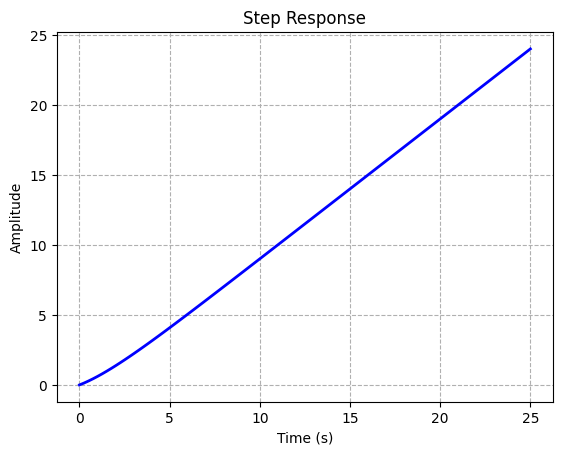

In [8]:
# Plot Step Response
plt.plot(t, y, label='Output y(t)', color='blue', linewidth=2)
plt.title('Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--')

In [9]:
# Print Analysis
print(f"Poles: {ctrl.poles(sys)}")
print(f"Zeros: {ctrl.zeros(sys)}")

Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


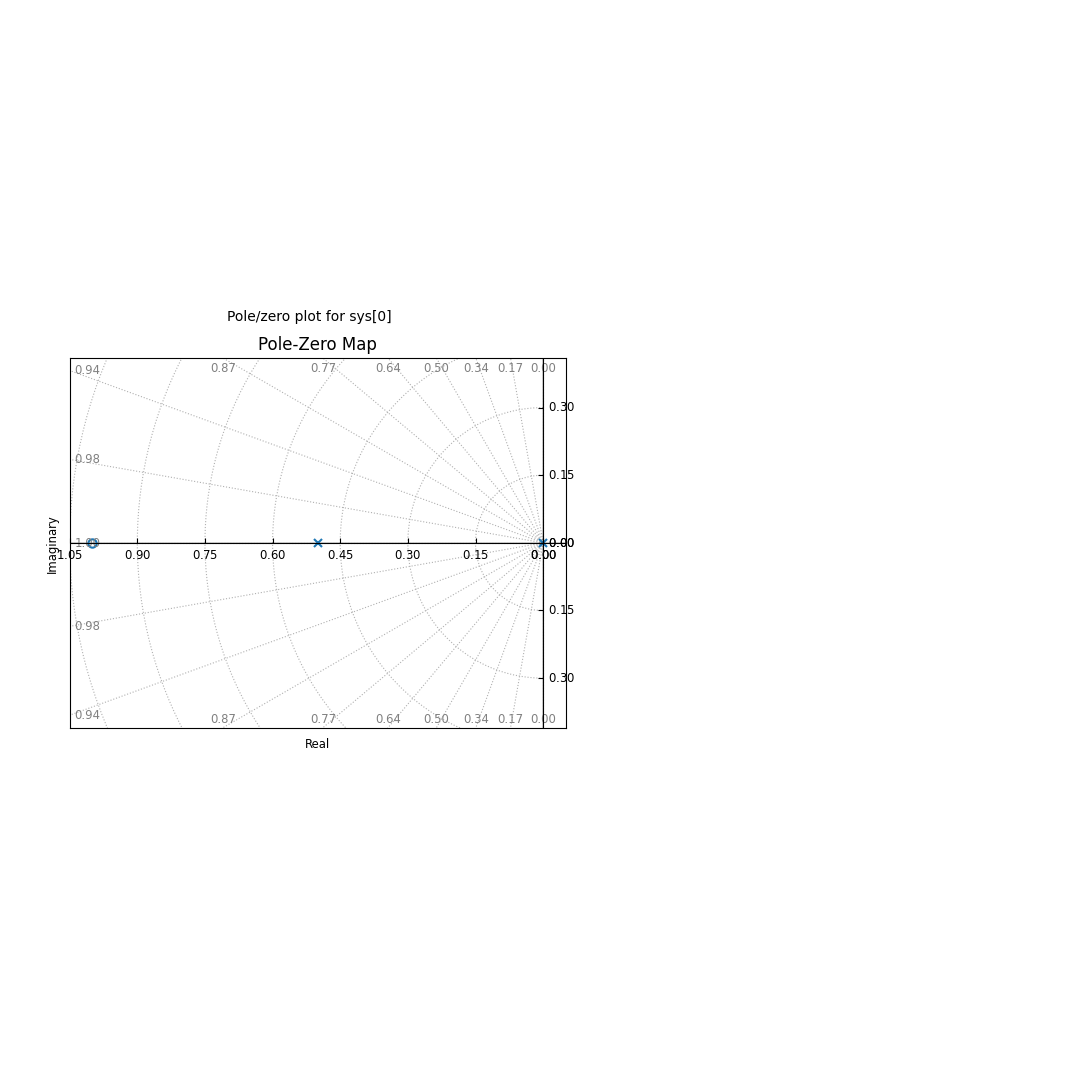

In [10]:
# Plot Pole-Zero Map
ctrl.pzmap(sys, grid=True)
plt.title('Pole-Zero Map')

plt.show()